In [22]:
import pandas as pd
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/twitter_validation.csv',header=None)
df.columns=['id','source','sentiment','text']
df

,id,source,sentiment,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [50]:
df.iloc[777]

,777
sentiment,1
text,Don’t tweet much but here’s what I’ve been up ...


In [23]:
df.drop(columns=['id','source'],inplace=True)

In [24]:
df

,sentiment,text
0,Irrelevant,I mentioned on Facebook that I was struggling ...
1,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,Negative,@Microsoft Why do I pay for WORD when it funct...
3,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,Neutral,Now the President is slapping Americans in the...
...,...,...
995,Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,Positive,Today sucked so it’s time to drink wine n play...
998,Positive,Bought a fraction of Microsoft today. Small wins.


In [25]:
senti=[df['sentiment'].unique()]

<Axes: xlabel='sentiment', ylabel='count'>

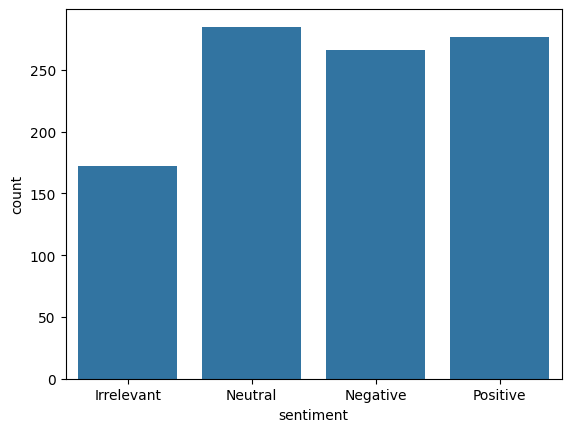

In [26]:
import seaborn as sns
sns.countplot(df,x=df['sentiment'])

In [27]:
df=df.loc[df['sentiment']!='Irrelevant']
df

,sentiment,text
1,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,Negative,@Microsoft Why do I pay for WORD when it funct...
3,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,Neutral,Now the President is slapping Americans in the...
5,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
993,Negative,Please explain how this is possible! How can t...
994,Positive,Good on Sony. As much as I want to see the new...
997,Positive,Today sucked so it’s time to drink wine n play...
998,Positive,Bought a fraction of Microsoft today. Small wins.


In [28]:
df.reset_index(drop=True,inplace=True)
df

,sentiment,text
0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Negative,@Microsoft Why do I pay for WORD when it funct...
2,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Neutral,Now the President is slapping Americans in the...
4,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
823,Negative,Please explain how this is possible! How can t...
824,Positive,Good on Sony. As much as I want to see the new...
825,Positive,Today sucked so it’s time to drink wine n play...
826,Positive,Bought a fraction of Microsoft today. Small wins.


In [29]:
df['sentiment']=df['sentiment'].map({'Positive':1,'Negative':-1,'Neutral':0})
df

/tmp/ipykernel_5468/3113957670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment']=df['sentiment'].map({'Positive':1,'Negative':-1,'Neutral':0})


,sentiment,text
0,0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,-1,@Microsoft Why do I pay for WORD when it funct...
2,-1,"CSGO matchmaking is so full of closet hacking,..."
3,0,Now the President is slapping Americans in the...
4,-1,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
823,-1,Please explain how this is possible! How can t...
824,1,Good on Sony. As much as I want to see the new...
825,1,Today sucked so it’s time to drink wine n play...
826,1,Bought a fraction of Microsoft today. Small wins.


In [30]:
text=df['text']
text=text.str.replace('[^A-z ]','',regex=True)
text

,text
0,BBC News Amazon boss Jeff Bezos rejects claim...
1,Microsoft Why do I pay for WORD when it functi...
2,CSGO matchmaking is so full of closet hacking ...
3,Now the President is slapping Americans in the...
4,Hi EAHelp Ive had Madeleine McCann in my cella...
...,...
823,Please explain how this is possible How can th...
824,Good on Sony As much as I want to see the new ...
825,Today sucked so its time to drink wine n play ...
826,Bought a fraction of Microsoft today Small wins


In [31]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words('english')
sw

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [42]:
from nltk.stem import SnowballStemmer

nltk.download('punkt_tab')
stemmer=SnowballStemmer('english')
text=text.apply(lambda line: [stemmer.stem(word) for word in nltk.word_tokenize(line) if word.lower() not in sw and len(word)>1]).apply(lambda word:' '.join(word))
text
t=text[777]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid=TfidfVectorizer()
td=tfid.fit_transform(text)
print(td)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9625 stored elements and shape (828, 3746)>
  Coords	Values
  (0, 268)	0.3040742922841671
  (0, 2096)	0.24408680129322063
  (0, 95)	0.18276776438474102
  (0, 365)	0.27408054678869387
  (0, 1659)	0.28652907591314114
  (0, 298)	0.3040742922841671
  (0, 2694)	0.3040742922841671
  (0, 535)	0.2644247174427998
  (0, 596)	0.20232598686548126
  (0, 21)	0.2644247174427998
  (0, 1805)	0.15689826458535408
  (0, 866)	0.28652907591314114
  (0, 732)	0.3040742922841671
  (0, 269)	0.3040742922841671
  (1, 1963)	0.25806107780480547
  (1, 2267)	0.32370302649851723
  (1, 3649)	0.37845128466985584
  (1, 1141)	0.41986674318312966
  (1, 2496)	0.3956402530026917
  (1, 2815)	0.41986674318312966
  (1, 527)	0.41986674318312966
  (2, 694)	0.2816745226319313
  (2, 1909)	0.3989005165790297
  (2, 1138)	0.3815699029840016
  (2, 555)	0.42332664454383956
  :	:
  (825, 363)	0.22995722808098484
  (825, 3333)	0.25427636267451453
  (825, 582)	0.2515453597566906

In [34]:
x=td.toarray()

In [35]:
y=df.sentiment
y

,sentiment
0,0
1,-1
2,-1
3,0
4,-1
...,...
823,-1
824,1
825,1
826,1


In [36]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.30,random_state=11)

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import classification_report
model=[KNeighborsClassifier(),RandomForestClassifier(random_state=11),AdaBoostClassifier(random_state=11),MultinomialNB()]
for obj in model:
  obj.fit(x_tr,y_tr)
  y_new=obj.predict(tfid.transform([t]).toarray())
  print(y_new)
  y_pred=obj.predict(x_te)
  print(obj,'\n',classification_report(y_te,y_pred))


[1]
KNeighborsClassifier() 
               precision    recall  f1-score   support

          -1       0.37      0.60      0.46        70
           0       0.50      0.39      0.44        94
           1       0.55      0.40      0.46        85

    accuracy                           0.45       249
   macro avg       0.47      0.46      0.45       249
weighted avg       0.48      0.45      0.45       249

[1]
RandomForestClassifier(random_state=11) 
               precision    recall  f1-score   support

          -1       0.46      0.46      0.46        70
           0       0.58      0.47      0.52        94
           1       0.52      0.64      0.57        85

    accuracy                           0.52       249
   macro avg       0.52      0.52      0.52       249
weighted avg       0.53      0.52      0.52       249

[0]
AdaBoostClassifier(random_state=11) 
               precision    recall  f1-score   support

          -1       0.51      0.26      0.34        70
           0